# OpenModelica Python Interface

- free, open source, highly portable Python based interactive session handler for Modelica scripting

- provides the modeler with components for creating a complete Modelica modeling, compilation and simulation environment **based on the latest OpenModelica library standard available**

- OMPython is architectured to **combine both the solving strategy and model building**

- OMPython is **not a standalone package**, it depends upon the OpenModelica installation

- OMPython is implemented in Python and **depends on ZeroMQ - high performance asynchronous messaging library**

## OMPython Features

 - Interactive session handling, parsing, interpretation of commands and Modelica expressions for evaluation, simulation, plotting, etc.

 - Interface to the latest OpenModelica API calls.

 - Optimized parser results that give control over every element of the output.

 - Helper functions to allow manipulation on Nested dictionaries.

 - Easy access to the library and testing of OpenModelica commands.

In [1]:
import OMPython

In [2]:
my_library = OMPython.ModelicaSystem("MyLibrary/ClassicModel.mo", "ClassicModel")


Notification: Automatically loaded package ClassicModel default due to usage.



In [3]:
from OMPython import ModelicaSystem

import os
import matplotlib.pyplot as plt

In [4]:
print("MODELICAPATH:", os.environ.get("MODELICAPATH"))

MODELICAPATH: None


In [5]:
# Load the Model
# model = ModelicaSystem("../Modelica/Models/FirstOrder.mo", "FirstOrder")
model = ModelicaSystem("ClassicModel.mo", "ClassicModel")


Notification: Automatically loaded package ClassicModel default due to usage.



In [6]:
# Get the continuous states
continuous_states = model.getContinuous()
print("Continuous States:", continuous_states)

Continuous States: {'x': None, 'y': None, 'der(x)': None, 'der(y)': None}


In [7]:
# Define simulation options
stopTime = 140

model.setSimulationOptions([f"stopTime={stopTime}",
                            "stepSize=0.01",
                            "tolerance=1e-6",])

# Simulate the model
print("Simulating the model...")
model.simulate()

Simulating the model...
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


In [8]:
# Get the simulation results
t = model.getSolutions('time').flatten()
derx = model.getSolutions('der(x)').flatten()
x =model.getSolutions('x').flatten()
dery = model.getSolutions('der(y)').flatten()
y = model.getSolutions('y').flatten()

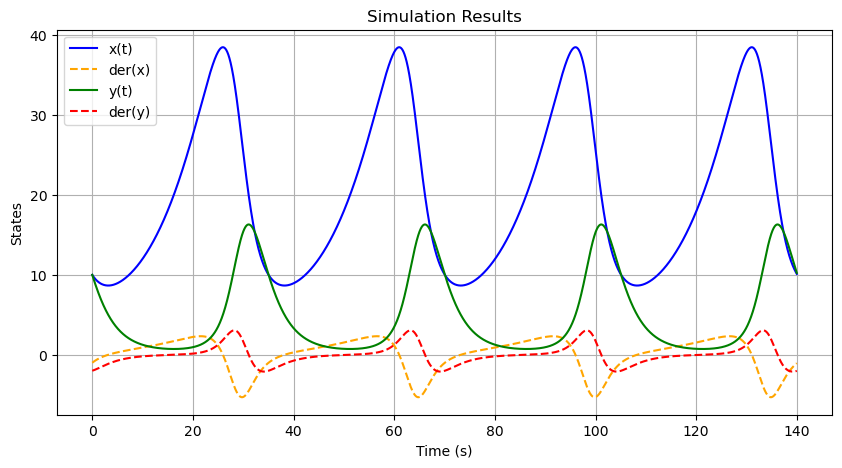

In [9]:
# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t, x, label='x(t)', color='blue')
plt.plot(t, derx, label='der(x)', color='orange', linestyle='--')
plt.plot(t, y, label='y(t)', color='green')
plt.plot(t, dery, label='der(y)', color='red', linestyle='--')

plt.title('Simulation Results')
plt.xlabel('Time (s)')
plt.ylabel('States')
plt.legend()
plt.grid()
plt.show()


------------------------